In [ ]:
!git clone https://github.com/Fighter20092392/X-SDD-A-New-benchmark.git
!ls -la X-SDD-A-New-benchmark/X-SDD/datas

Cloning into 'X-SDD-A-New-benchmark'...
remote: Enumerating objects: 1396, done.
remote: Counting objects: 100% (1396/1396), done.
remote: Compressing objects: 100% (1386/1386), done.
remote: Total 1396 (delta 10), reused 1391 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (1396/1396), 5.94 MiB | 9.64 MiB/s, done.
Resolving deltas: 100% (10/10), done.
total 44
drwxr-xr-x 9 root root  4096 Oct 15 09:44  .
drwxr-xr-x 3 root root  4096 Oct 15 09:44  ..
drwxr-xr-x 2 root root  4096 Oct 15 09:43 'finishing roll printing'
drwxr-xr-x 2 root root  4096 Oct 15 09:43 'iron sheet ash'
drwxr-xr-x 2 root root  4096 Oct 15 09:43 'oxide scale of plate system'
drwxr-xr-x 2 root root  4096 Oct 15 09:43 'oxide scale of temperature system'
drwxr-xr-x 2 root root 12288 Oct 15 09:44 'red iron'
drwxr-xr-x 2 root root  4096 Oct 15 09:44 'slag inclusion'
drwxr-xr-x 2 root root  4096 Oct 15 09:44 'surface scratch'


In [ ]:
!pip install --quiet scikit-image matplotlib opencv-python torch torchvision albumentations

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage.color import rgb2lab, lab2rgb
from skimage.feature import local_binary_pattern
import cv2
from glob import glob

print("libs OK")


libs OK


1360 images trouvées


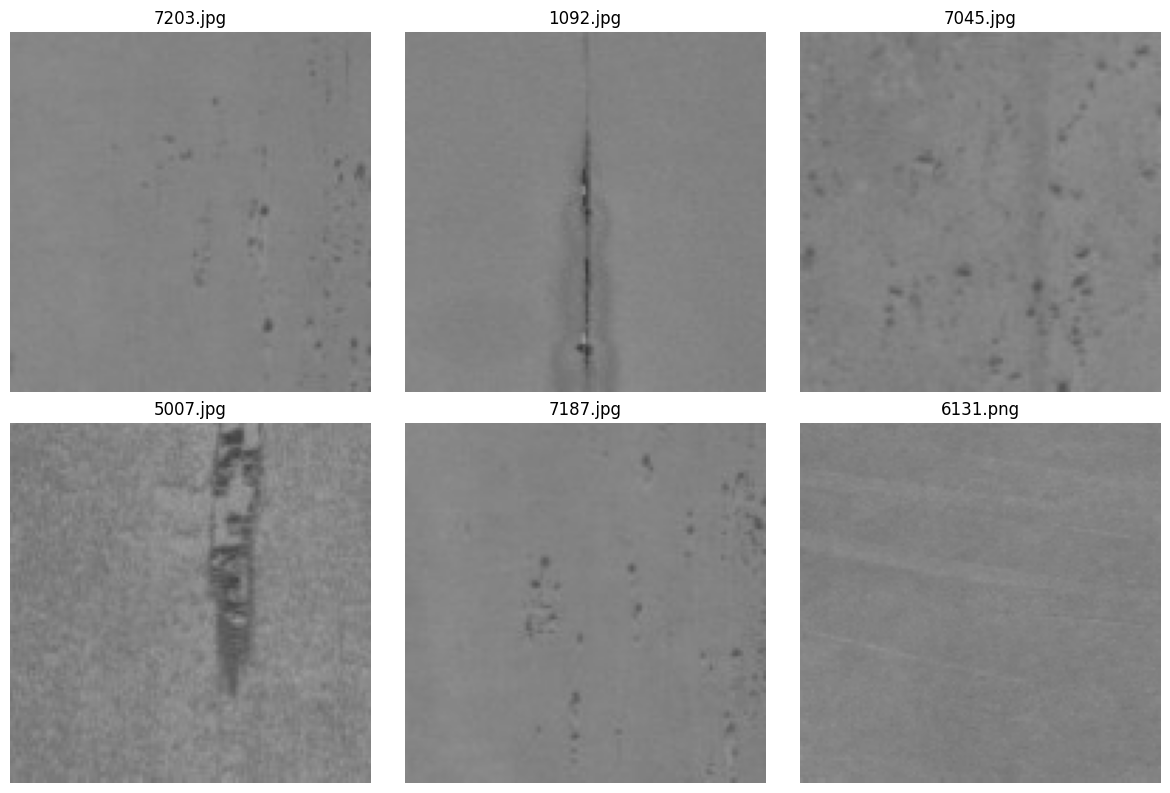

In [ ]:
# Chemin vers les images
image_folder = "X-SDD-A-New-benchmark/X-SDD/datas"  # exemple
# cherche récursivement les png/jpg
img_paths = glob(os.path.join(image_folder, "**", "*.png"), recursive=True) + \
            glob(os.path.join(image_folder, "**", "*.jpg"), recursive=True) + \
            glob(os.path.join(image_folder, "**", "*.jpeg"), recursive=True)

print(f"{len(img_paths)} images trouvées")
# affiche 6 images aléatoires
sample = random.sample(img_paths, min(6, len(img_paths)))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for ax, p in zip(axes, sample):
    im = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    ax.imshow(im)
    ax.set_title(os.path.basename(p))
    ax.axis('off')
plt.tight_layout()


(224, 224, 3) float64


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

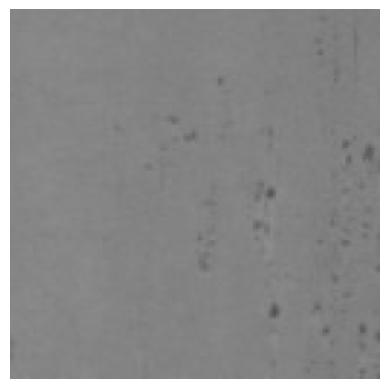

In [ ]:
# Prétraitement
def load_and_preprocess(path, target_size=(224,224)):
    im = cv2.imread(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    # resize si nécessaire
    if target_size is not None:
        im = cv2.resize(im, target_size, interpolation=cv2.INTER_AREA)
    # convertir en float [0,1]
    im_f = img_as_float(im)  # skimage float
    return im_f

# test
p = sample[0]
im = load_and_preprocess(p)
print(im.shape, im.dtype)
plt.imshow(im); plt.axis('off')


nombre de segments trouvés (unique ids) : 287


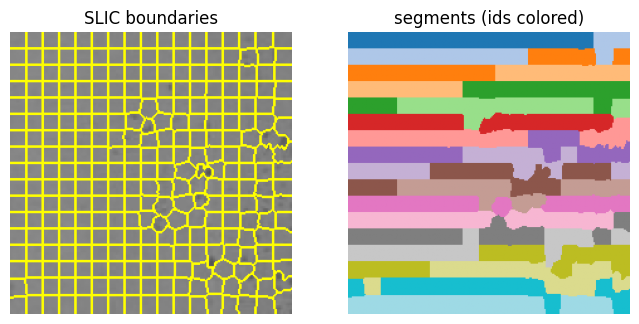

In [ ]:
def slic_and_display(image, n_segments=300, compactness=10, sigma=0):
    """
    image : image float RGB [0,1]
    retourne segments et image avec frontières
    """
    # convert to Lab can help SLIC sur couleur
    image_lab = rgb2lab(image)
    segments = slic(image_lab, n_segments=n_segments, compactness=compactness, sigma=sigma, start_label=1)
    # image avec frontières pour visualiser
    img_bounds = mark_boundaries(image, segments)
    return segments, img_bounds

# test sur une image
segments, img_bounds = slic_and_display(im, n_segments=300, compactness=10, sigma=0.5)
print("nombre de segments trouvés (unique ids) :", len(np.unique(segments)))
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img_bounds); plt.title("SLIC boundaries"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(segments, cmap='tab20'); plt.title("segments (ids colored)"); plt.axis('off')
plt.show()


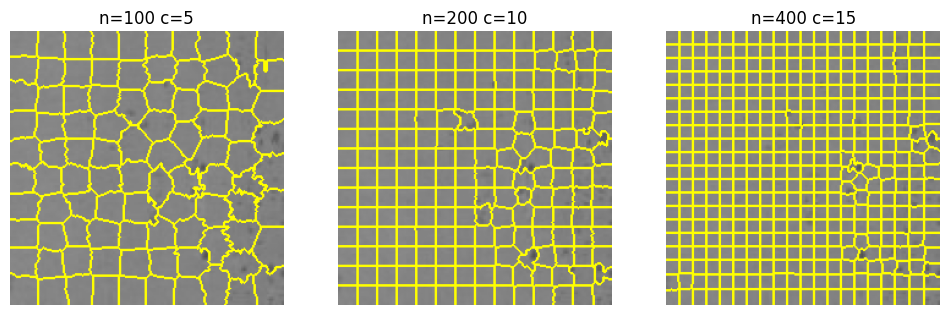

In [ ]:
def compare_params(path, params_list):
    im = load_and_preprocess(path)
    n = len(params_list)
    cols = n
    plt.figure(figsize=(4*cols,4))
    for i, p in enumerate(params_list):
        s, b = slic_and_display(im, n_segments=p['n_segments'], compactness=p['compactness'], sigma=p.get('sigma',0))
        plt.subplot(1, cols, i+1)
        plt.imshow(b)
        plt.title(f"n={p['n_segments']} c={p['compactness']}")
        plt.axis('off')
    plt.show()

# Exemple de comparaison
params = [
    {'n_segments':100, 'compactness':5},
    {'n_segments':200, 'compactness':10},
    {'n_segments':400, 'compactness':15}
]
compare_params(sample[0], params)


In [ ]:
def to_grayscale(image_rgb, for_lbp=False):
    """
    image_rgb : (H, W, 3) float [0,1]
    if for_lbp=True -> retourne uint8 (0-255)
    sinon -> retourne float32 [0,1]
    """
    gray_uint8 = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    if for_lbp:
        return gray_uint8  # uint8 direct pour LBP
    else:
        return gray_uint8.astype(np.float32) / 255.0


In [ ]:
def extract_superpixel_features(image_rgb, segments):
    """
    image_rgb : array (H, W, 3) float [0,1]
    segments : array (H, W) avec IDs de superpixels
    Retourne :
       - features : dict {superpixel_id: feature_vector}
    """
    # --- Conversion grayscale (2 versions) ---
    # Pour mean/std -> en float
    gray_float = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    # Pour LBP -> en uint8
    gray_uint8 = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    unique_ids = np.unique(segments)
    H, W = gray_float.shape

    # LBP settings
    radius = 1
    n_points = 8 * radius

    features_dict = {}

    for sid in unique_ids:
        mask = (segments == sid)
        pixel_indices = np.argwhere(mask)

        if len(pixel_indices) == 0:
            continue

        # 1) Intensité moyenne
        mean_intensity = gray_float[mask].mean()

        # 2) Écart-type
        std_intensity = gray_float[mask].std()

        # 3) LBP histogram (8 bins) sur uint8
        lbp = local_binary_pattern(gray_uint8, n_points, radius, method='uniform')
        lbp_vals = lbp[mask]
        bins = np.arange(0, n_points + 2)  # 'uniform' -> n_points+2 bins
        lbp_hist, _ = np.histogram(lbp_vals, bins=bins, density=True)

        # 4) Centroïde (x,y normalisés)
        y_coords, x_coords = pixel_indices[:, 0], pixel_indices[:, 1]
        cx = x_coords.mean() / W
        cy = y_coords.mean() / H

        # 5) Taille (nb pixels)
        size_sp = len(pixel_indices)

        # Vecteur final = 13 features
        feature_vector = np.concatenate([
            [mean_intensity],
            [std_intensity],
            lbp_hist,         # 8 valeurs
            [cx, cy],
            [size_sp]
        ]).astype(np.float32)

        features_dict[sid] = feature_vector

    return features_dict


Test features 2 superpixel Image 1

In [ ]:
features = extract_superpixel_features(im, segments)
print("Nombre de superpixels :", len(features))

# Afficher les 2 premiers vecteurs
count = 0
for k, v in features.items():
    print(f"Superpixel {k} -> {v.shape} valeurs")
    print(v)
    count += 1
    if count == 2:
        break


Nombre de superpixels : 287
Superpixel 1 -> (14,) valeurs
[5.2193993e-01 6.1414507e-03 0.0000000e+00 4.7337279e-02 5.9171598e-03
 1.5976331e-01 4.1420117e-02 3.4319526e-01 4.7337279e-02 4.1420117e-02
 3.1360948e-01 2.6785715e-02 2.6785715e-02 1.6900000e+02]
Superpixel 2 -> (14,) valeurs
[5.2641845e-01 3.6764380e-03 0.0000000e+00 1.1834320e-02 0.0000000e+00
 1.5976331e-01 5.9171598e-03 2.6627219e-01 1.7751480e-02 1.3609467e-01
 4.0236688e-01 8.4821425e-02 2.6785715e-02 1.6900000e+02]


In [ ]:
def build_feature_matrix(features_dict):
    """
    features_dict : {superpixel_id -> vecteur de 13 valeurs}
    Retourne :
       X : np.array shape (N_superpixels, 13)
       sp_ids : liste triée des superpixel_id (pour cohérence)
    """
    sp_ids = sorted(features_dict.keys())
    X = np.array([features_dict[sid] for sid in sp_ids], dtype=np.float32)
    return X, sp_ids


In [ ]:
X, sp_ids = build_feature_matrix(features)
print("X shape :", X.shape)
print("Exemple 1er vecteur :", X[0])

X shape : (287, 14)
Exemple 1er vecteur : [5.2193993e-01 6.1414507e-03 0.0000000e+00 4.7337279e-02 5.9171598e-03
 1.5976331e-01 4.1420117e-02 3.4319526e-01 4.7337279e-02 4.1420117e-02
 3.1360948e-01 2.6785715e-02 2.6785715e-02 1.6900000e+02]


In [ ]:
def build_adjacency_from_segments(segments):
    """
    segments : array (H, W) contenant les IDs des superpixels
    Retourne :
      edge_index : np.array shape (2, E) avec E = nb d'arêtes non orientées doublées
    """
    H, W = segments.shape
    edges = set()

    # vérifier 4 voisins (haut, bas, gauche, droite)
    for y in range(H):
        for x in range(W):
            sid = segments[y, x]
            # voisin droit
            if x + 1 < W:
                sid_r = segments[y, x+1]
                if sid != sid_r:
                    edges.add(tuple(sorted((sid, sid_r))))
            # voisin bas
            if y + 1 < H:
                sid_b = segments[y+1, x]
                if sid != sid_b:
                    edges.add(tuple(sorted((sid, sid_b))))

    # convertir en edge_index orienté (doublé pour GNN)
    edge_list = []
    for (a, b) in edges:
        edge_list.append([a, b])
        edge_list.append([b, a])

    edge_index = np.array(edge_list).T  # shape (2, E)
    return edge_index

In [ ]:
edge_index = build_adjacency_from_segments(segments)
print("edge_index shape :", edge_index.shape)  # (2, E)
print(edge_index[:, :10])

edge_index shape : (2, 1260)
[[206 217  36  53 158 177  67  68 247 264]
 [217 206  53  36 177 158  68  67 264 247]]


In [ ]:
def remap_edge_index(edge_index, sp_ids):
    """
    edge_index : (2, E) avec sid originaux
    sp_ids : liste triée des superpixel_id (ex: [1,2,4,7,...])
    Retourne :
      edge_index_new (2, E) remappé sur [0..N-1]
    """
    id_map = {sid: i for i, sid in enumerate(sp_ids)}
    edge_index_new = np.vectorize(id_map.get)(edge_index)
    return edge_index_new

In [ ]:
edge_index = build_adjacency_from_segments(segments)
edge_index = remap_edge_index(edge_index, sp_ids)

print(edge_index.shape)  # (2, E)
print(edge_index[:, :10])

(2, 1260)
[[205 216  35  52 157 176  66  67 246 263]
 [216 205  52  35 176 157  67  66 263 246]]


In [ ]:
import torch

# params: adapte si nécessaire
mi_idx = 0     # mean intensity index in X
cx_idx = 11
cy_idx = 12
size_idx = 13

def compute_boundary_length_for_edges(segments, edge_pairs, sp_id_to_original):
    """
    segments : HxW labels (original ids, not remapped)
    edge_pairs : list of (orig_id_a, orig_id_b) tuples (UNDIRECTED, sorted)
    sp_id_to_original : mapping index->original id (sp_ids list)
    Retourne dict {(a,b): boundary_length}
    """
    H, W = segments.shape
    # build a dict to count adjacency pairs by scanning neighbors
    boundary_counts = {}
    # scan right and down neighbors
    for y in range(H):
        for x in range(W):
            a = segments[y, x]
            if x + 1 < W:
                b = segments[y, x+1]
                if a != b:
                    key = tuple(sorted((int(a), int(b))))
                    boundary_counts[key] = boundary_counts.get(key, 0) + 1
            if y + 1 < H:
                b = segments[y+1, x]
                if a != b:
                    key = tuple(sorted((int(a), int(b))))
                    boundary_counts[key] = boundary_counts.get(key, 0) + 1
    # For any requested pair not present, default to 0
    out = {pair: boundary_counts.get(tuple(sorted(pair)), 0) for pair in edge_pairs}
    return out

def build_edge_attr_from_X_segments(X, edge_index, segments, sp_ids, normalize=True):
    """
    X : (N,14) numpy
    edge_index : (2, E) numpy with indices in [0..N-1] (remapped)
    segments : HxW labels (original ids matching sp_ids entries)
    sp_ids : list of original superpixel ids (len N), ordered like X rows
    Returns:
       edge_attr : numpy array shape (E, 3)
    """
    N = X.shape[0]
    # Sanity
    assert edge_index.shape[0] == 2
    E = edge_index.shape[1]

    # mean intensity and centroids from X
    mean_int = X[:, mi_idx].astype(np.float32)   # shape (N,)
    cx = X[:, cx_idx].astype(np.float32)
    cy = X[:, cy_idx].astype(np.float32)
    # build mapping original_id -> row_index
    orig_to_row = {orig_id: i for i, orig_id in enumerate(sp_ids)}

    # We'll compute boundary lengths for UNDIRECTED unique pairs
    # But edge_index currently contains directed edges (u->v and v->u)
    # Build unique undirected pairs using original ids
    undirected_pairs = set()
    # Also keep list of directed edges to fill edge_attr in order
    directed_edges_orig = []  # list of (orig_u, orig_v)
    for k in range(E):
        u = int(edge_index[0, k])
        v = int(edge_index[1, k])
        orig_u = sp_ids[u]
        orig_v = sp_ids[v]
        directed_edges_orig.append((orig_u, orig_v))
        undirected_pairs.add(tuple(sorted((orig_u, orig_v))))
    undirected_pairs = list(undirected_pairs)

    # Compute boundary lengths for all undirected pairs (using original labels in segments)
    boundary_dict = compute_boundary_length_for_edges(segments, undirected_pairs, sp_ids)

    # Now build edge_attr per directed edge in edge_index order
    edge_attr = np.zeros((E, 3), dtype=np.float32)
    for k in range(E):
        u = int(edge_index[0, k])
        v = int(edge_index[1, k])
        orig_u = sp_ids[u]
        orig_v = sp_ids[v]

        # 1) absolute difference of mean intensity
        diff_mean = float(abs(mean_int[u] - mean_int[v]))

        # 2) euclidean distance between centroids (cx,cy are normalized [0,1])
        dx = float(cx[u] - cx[v])
        dy = float(cy[u] - cy[v])
        centroid_dist = float((dx*dx + dy*dy)**0.5)

        # 3) boundary length (shared pixel count)
        blen = float(boundary_dict.get(tuple(sorted((orig_u, orig_v))), 0))

        edge_attr[k, 0] = diff_mean
        edge_attr[k, 1] = centroid_dist
        edge_attr[k, 2] = blen

    # Option: normalize each column to zero-mean/unit-variance (helpful for training)
    if normalize:
        # avoid division by zero
        means = edge_attr.mean(axis=0)
        stds = edge_attr.std(axis=0)
        stds[stds == 0] = 1.0
        edge_attr = (edge_attr - means) / stds

    return edge_attr

# Exemple d'utilisation (sur ton graphe courant) :
# Assure-toi que sp_ids est la liste utilisée pour construire X (origine->row mapping)
# edge_index numpy déjà remappé (0..N-1).
edge_attr = build_edge_attr_from_X_segments(X, edge_index, segments, sp_ids, normalize=True)

print("edge_attr shape:", edge_attr.shape)  # (E, 3)
print("quelques edge attrs:", edge_attr[:6])


edge_attr shape: (1260, 3)
quelques edge attrs: [[-0.1895223  -0.5786394   0.30648085]
 [-0.1895223  -0.5786394   0.30648085]
 [-0.09075867 -0.4982679   0.30648085]
 [-0.09075867 -0.4982679   0.30648085]
 [-0.06695807 -0.49826396  0.30648085]
 [-0.06695807 -0.49826396  0.30648085]]


In [ ]:
!pip install --quiet torch_geometric
import torch
from torch_geometric.data import Data

In [ ]:
data = Data(
    x=torch.tensor(X, dtype=torch.float32),
    edge_index=torch.tensor(edge_index, dtype=torch.long),
    edge_attr=torch.tensor(edge_attr, dtype=torch.float32)
)

print(data)
print("x shape:", data.x.shape)
print("edge_index shape:", data.edge_index.shape)
print("edge_attr shape:", data.edge_attr.shape)


Data(x=[287, 14], edge_index=[2, 1260], edge_attr=[1260, 3])
x shape: torch.Size([287, 14])
edge_index shape: torch.Size([2, 1260])
edge_attr shape: torch.Size([1260, 3])


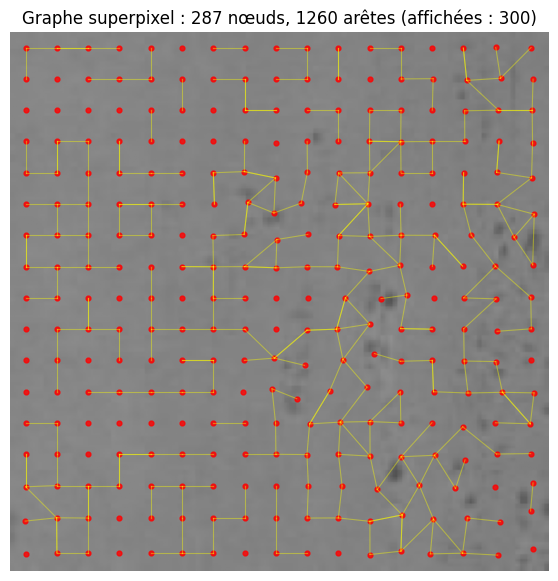

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_graph_on_image(image, X, edge_index, sample_edges=300):
    """
    image : RGB float [0,1]
    X : features matrix (N, 14)
    edge_index : (2, E) numpy
    sample_edges : nombre d'arêtes à afficher (pour la lisibilité)
    """
    H, W, _ = image.shape

    # centroïdes normalisés dans X (colonnes 11 et 12)
    cx = X[:, 11] * W
    cy = X[:, 12] * H

    plt.figure(figsize=(7,7))
    plt.imshow(image)

    # Tirer un sous-ensemble d'arêtes si trop nombreuses
    E = edge_index.shape[1]
    if E > sample_edges:
        idx = random.sample(range(E), sample_edges)
    else:
        idx = range(E)

    for i in idx:
        u = edge_index[0, i]
        v = edge_index[1, i]
        plt.plot([cx[u], cx[v]], [cy[u], cy[v]], color='yellow', linewidth=0.8, alpha=0.4)

    # Nœuds (centroïdes)
    plt.scatter(cx, cy, c='red', s=12, alpha=0.8)

    plt.title(f"Graphe superpixel : {len(cx)} nœuds, {E} arêtes (affichées : {len(idx)})")
    plt.axis('off')
    plt.show()

# Exemple d'utilisation
visualize_graph_on_image(im, X, edge_index, sample_edges=300)

